# TP 3 — Modelado y Simulación por medio de Múltiples Agentes
## Modelo de Segregación de Schelling

**Asignatura:** Simulación y Procesos Estocásticos  
**Facultad de Química e Ingeniería del Rosario — UCA**  

---

### Configuración del modelo

| Parámetro | Valor |
|---|---|
| Tamaño de grilla | 50 × 50 = 2500 celdas |
| Celdas vacías | 20% (~500 celdas) |
| Agentes Grupo A | ~1000 |
| Agentes Grupo B | ~1000 |
| Vecindad | Moore (8 celdas) |
| Convención | El agente se incluye en su propio recuento |
| Umbral Dinámica 2 | 3/8 ≈ 0.375 (clásico de Schelling) |


In [1]:
# ── Imports y setup ──────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'funciones'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from grid import inicializar_grilla
from dynamics import correr_simulacion, calcular_fraccion_descontentos
from metrics import (indice_similitud, fraccion_descontentos_d1,
                     fraccion_descontentos_d2, es_sistema_frustrado)
from visualization import (plot_snapshots, plot_convergencia,
                            plot_comparacion_metricas)
from ising import (correr_ising, curva_magnetizacion_vs_temperatura,
                   plot_ising_snapshots, plot_magnetizacion_vs_T)

# Parámetros globales
N           = 50         # Tamaño de grilla
FRAC_VACIA  = 0.20       # 20% de celdas vacías
UMBRAL_D2   = 3/8        # Umbral Schelling clásico
SEED        = 42

print('✓ Módulos importados correctamente')
print(f'  Grilla: {N}×{N} | Vacías: {FRAC_VACIA:.0%} | Umbral D2: {UMBRAL_D2:.3f}')


✓ Módulos importados correctamente
  Grilla: 50×50 | Vacías: 20% | Umbral D2: 0.375


---
## Punto 1 — Dinámica 1: Preferencia por ser MINORÍA

**Regla:** Un agente está *contento* cuando es **minoría** en su vecindad:  
fracción de vecinos iguales (incluyéndose) **< 0.5**.

**Mecánica de mudanza:**
1. Se selecciona al azar un par de agentes de distinto color.
2. Si **ambos** están descontentos → intercambian posiciones.
3. Se repite hasta convergencia o máximo de intentos.

**Hipótesis:** Como cada agente quiere ser el diferente, cualquier mejora para uno empeora al otro. Se espera que el sistema sea **frustrado** y no converja a un estado estacionario limpio.

In [2]:
# ── Inicializar grilla ────────────────────────────────────────────────────────
grilla_inicial = inicializar_grilla(N, FRAC_VACIA, seed=SEED)

print(f'Grilla inicializada:')
print(f'  Celdas vacías:  {np.sum(grilla_inicial == 0):4d} ({np.sum(grilla_inicial == 0)/N**2:.1%})')
print(f'  Agentes A (1):  {np.sum(grilla_inicial == 1):4d} ({np.sum(grilla_inicial == 1)/N**2:.1%})')
print(f'  Agentes B (2):  {np.sum(grilla_inicial == 2):4d} ({np.sum(grilla_inicial == 2)/N**2:.1%})')
print(f'\nFracción inicial descontentos (D1): {fraccion_descontentos_d1(grilla_inicial):.3f}')
print(f'Índice inicial de similitud:        {indice_similitud(grilla_inicial):.3f}')


Grilla inicializada:
  Celdas vacías:   500 (20.0%)
  Agentes A (1):  1000 (40.0%)
  Agentes B (2):  1000 (40.0%)

Fracción inicial descontentos (D1): 0.421
Índice inicial de similitud:        0.507


In [3]:
# ── Correr simulación Dinámica 1 ──────────────────────────────────────────────
print('Corriendo Dinámica 1 (querer ser minoría)...')
print('Esto puede tardar ~60 segundos en una grilla 50×50...')

snaps_d1, labels_d1, hist_d1 = correr_simulacion(
    grilla_inicial       = grilla_inicial,
    dinamica             = 1,
    n_intentos_max       = 800_000,
    intentos_sin_swap_para_detener = 15_000,
    snapshots_en         = [0, 100, 300, 700, 1500, 3000],
    seed                 = SEED
)

print(f'\nSimulación terminada.')
print(f'Snapshots capturados: {len(snaps_d1)}')
for i, (g, lbl) in enumerate(zip(snaps_d1, labels_d1)):
    frac = fraccion_descontentos_d1(g)
    sim  = indice_similitud(g)
    print(f'  [{i}] {lbl:30s}  desc={frac:.3f}  similitud={sim:.3f}')


Corriendo Dinámica 1 (querer ser minoría)...
Esto puede tardar ~60 segundos en una grilla 50×50...

Simulación terminada.
Snapshots capturados: 4
  [0] Estado inicial                  desc=0.421  similitud=0.507
  [1] 100 mudanzas                    desc=0.260  similitud=0.443
  [2] 300 mudanzas                    desc=0.064  similitud=0.363
  [3] Final (471 mudanzas)            desc=0.015  similitud=0.331


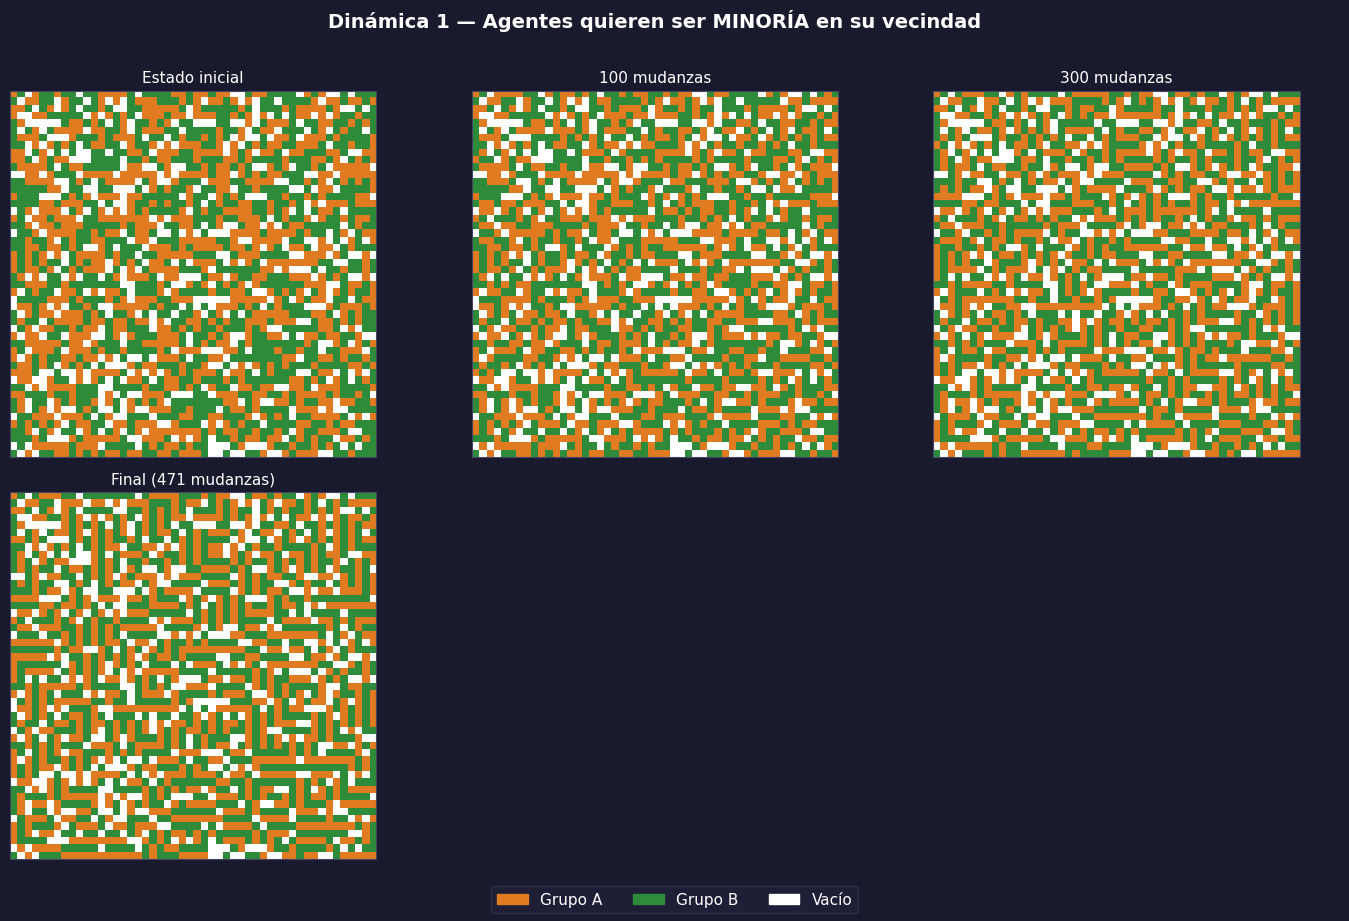

In [4]:
# ── Figura 1: 6 snapshots Dinámica 1 ─────────────────────────────────────────
plot_snapshots(
    snaps_d1, labels_d1,
    titulo="Dinámica 1 — Agentes quieren ser MINORÍA en su vecindad",
    guardar_como="fig_d1_snapshots.png"
)


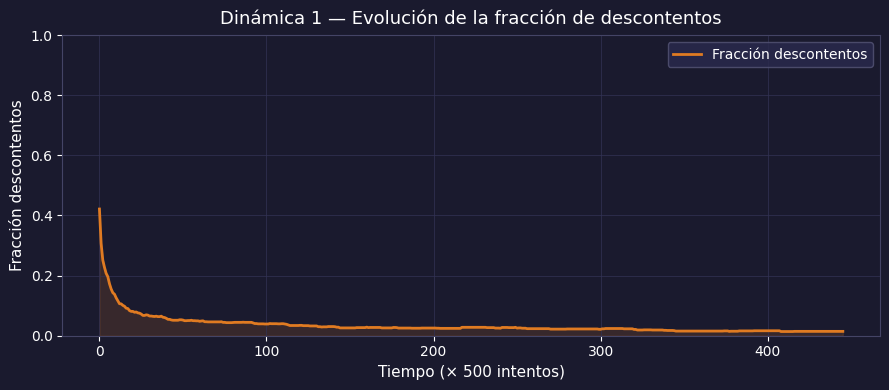


¿Sistema frustrado (D1)? False
Fracción de descontentos en estado final: 0.0145
Índice de similitud final: 0.3308


In [5]:
# ── Figura 2: Curva de convergencia D1 ───────────────────────────────────────
plot_convergencia(
    hist_d1,
    titulo="Dinámica 1 — Evolución de la fracción de descontentos",
    guardar_como="fig_d1_convergencia.png"
)

# Verificar si el sistema es frustrado
frustrado_d1 = es_sistema_frustrado(snaps_d1[-1], dinamica=1)
frac_final_d1 = fraccion_descontentos_d1(snaps_d1[-1])
print(f'\n¿Sistema frustrado (D1)? {frustrado_d1}')
print(f'Fracción de descontentos en estado final: {frac_final_d1:.4f}')
print(f'Índice de similitud final: {indice_similitud(snaps_d1[-1]):.4f}')


---
## Punto 2 — Dinámica 2: Preferencia por ser MAYORÍA (Schelling original)

**Regla:** Un agente está *contento* cuando es **mayoría** en su vecindad:  
fracción de vecinos iguales (incluyéndose) **≥ τ**, con **τ = 3/8 ≈ 0.375**.

Este es el caso original de Thomas Schelling (1969), que modeló la segregación residencial racial en ciudades de EE.UU. La paradoja clave: una preferencia **muy suave** (solo quiero que 3 de 8 vecinos sean iguales a mí) genera **segregación total** a nivel macro.

**Hipótesis:** El sistema **sí converge** a un estado estacionario segregado. Deberían formarse "barrios" monocolor bien definidos.

In [6]:
# ── Correr simulación Dinámica 2 ──────────────────────────────────────────────
print('Corriendo Dinámica 2 (Schelling — querer ser mayoría)...')

snaps_d2, labels_d2, hist_d2 = correr_simulacion(
    grilla_inicial       = grilla_inicial,   # misma grilla inicial
    dinamica             = 2,
    n_intentos_max       = 800_000,
    intentos_sin_swap_para_detener = 15_000,
    snapshots_en         = [0, 100, 300, 700, 1500, 3000],
    umbral_d2            = UMBRAL_D2,
    seed                 = SEED
)

print(f'\nSimulación terminada.')
print(f'Snapshots capturados: {len(snaps_d2)}')
for i, (g, lbl) in enumerate(zip(snaps_d2, labels_d2)):
    frac = fraccion_descontentos_d2(g, UMBRAL_D2)
    sim  = indice_similitud(g)
    print(f'  [{i}] {lbl:30s}  desc={frac:.3f}  similitud={sim:.3f}')


Corriendo Dinámica 2 (Schelling — querer ser mayoría)...

Simulación terminada.
Snapshots capturados: 4
  [0] Estado inicial                  desc=0.311  similitud=0.507
  [1] 100 mudanzas                    desc=0.204  similitud=0.593
  [2] 300 mudanzas                    desc=0.059  similitud=0.774
  [3] Final (400 mudanzas)            desc=0.016  similitud=0.829


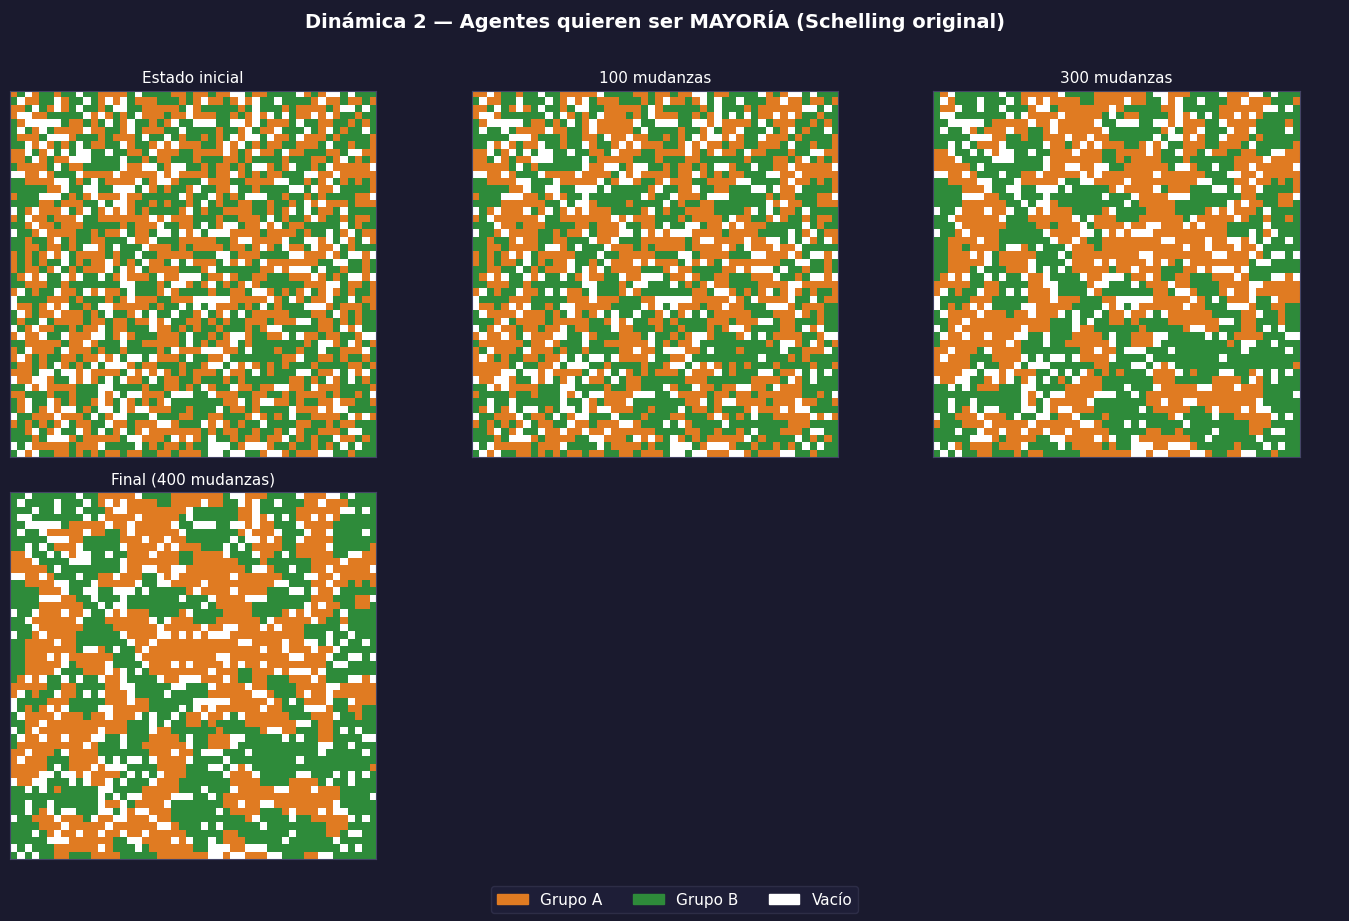

In [7]:
# ── Figura 3: 6 snapshots Dinámica 2 ─────────────────────────────────────────
plot_snapshots(
    snaps_d2, labels_d2,
    titulo="Dinámica 2 — Agentes quieren ser MAYORÍA (Schelling original)",
    guardar_como="fig_d2_snapshots.png"
)


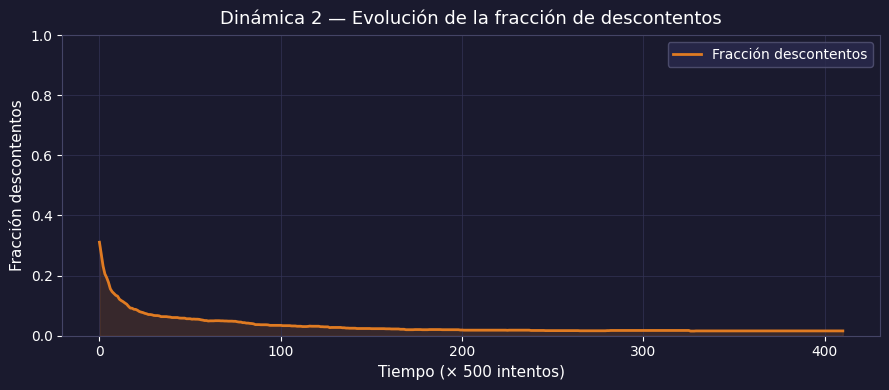


¿Sistema frustrado (D2)? False
Fracción de descontentos en estado final: 0.0160
Índice de similitud final: 0.8285


In [8]:
# ── Figura 4: Curva de convergencia D2 ───────────────────────────────────────
plot_convergencia(
    hist_d2,
    titulo="Dinámica 2 — Evolución de la fracción de descontentos",
    guardar_como="fig_d2_convergencia.png"
)

frustrado_d2 = es_sistema_frustrado(snaps_d2[-1], dinamica=2, umbral_d2=UMBRAL_D2)
frac_final_d2 = fraccion_descontentos_d2(snaps_d2[-1], UMBRAL_D2)
print(f'\n¿Sistema frustrado (D2)? {frustrado_d2}')
print(f'Fracción de descontentos en estado final: {frac_final_d2:.4f}')
print(f'Índice de similitud final: {indice_similitud(snaps_d2[-1]):.4f}')


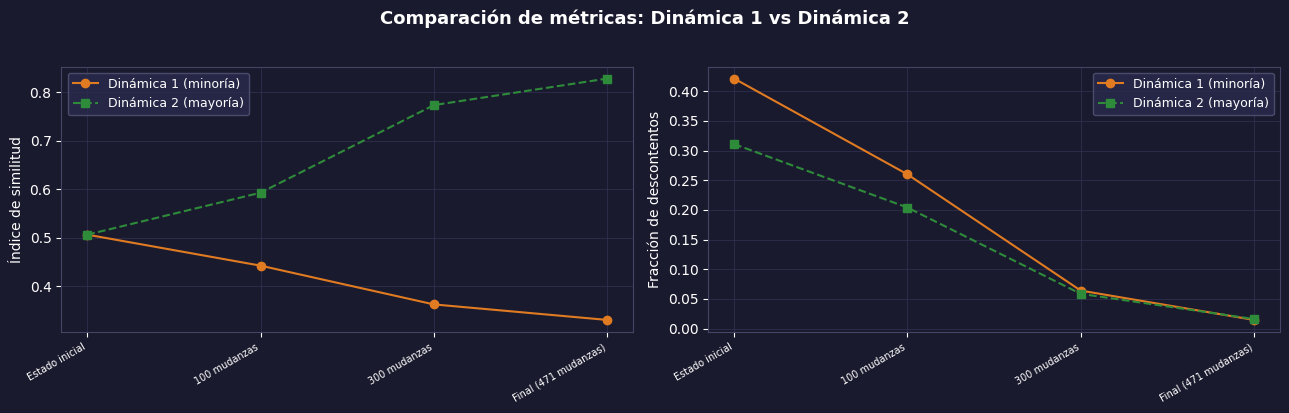

In [9]:
# ── Figura 5: Comparación D1 vs D2 ───────────────────────────────────────────
plot_comparacion_metricas(
    snaps_d1, labels_d1,
    snaps_d2, labels_d2,
    guardar_como="fig_comparacion.png"
)


---
## Punto 3 — Análisis del Estado Frustrado

### ¿Qué es un sistema frustrado?

Un sistema de múltiples agentes está **frustrado** cuando no existe ninguna configuración global capaz de satisfacer simultáneamente las preferencias de todos los agentes. El sistema queda "atrapado" en un ciclo donde cualquier mudanza que mejora la situación de un agente empeora la de otro.

### Por qué la Dinámica 1 es frustrada

En la Dinámica 1, un agente de tipo A quiere ser minoría (estar rodeado de B's). Pero si logra mudarse a un barrio de B's, ahora los agentes B vecinos tienen un A en su vecindad — lo cual los hace más felices si ellos también quieren ser minoría. Esto crea un conflicto circular:

```
Agente A en zona de B's → A contento, B's más descontentos
Agente B se muda a zona de A's → B contento, A's más descontentos  
→ Ciclo sin convergencia
```

**Analogía con spin glasses:** En física, esto se llama *frustración geométrica*. El ejemplo clásico es un triángulo antiferromagnético: si los espines deben ser opuestos a sus vecinos, el tercer vértice no puede satisfacer simultáneamente la condición con los otros dos.

### Interpretación en un problema real

La frustración aparece en muchos sistemas sociales y económicos reales:

1. **Mercado inmobiliario en barrios en transición:** Grupos que quieren ser "el barrio de moda" (ser únicos) generan gentrificación → barrios cambian de identidad → el grupo original pierde su unicidad y debe moverse de nuevo.

2. **Nichos de mercado:** Una empresa quiere diferenciarse (ser minoría en su nicho). Si tiene éxito, atrae imitadores → pierde diferenciación → debe reinventarse.

3. **Redes sociales y polarización dinámica:** Usuarios que buscan cámaras de eco del tipo opuesto (ej: "cuanto más diferente, más interesante") generan flujos circulares de contenido sin estado estable.

In [10]:
# ── Análisis cuantitativo del estado frustrado ────────────────────────────────
print('=' * 60)
print('RESUMEN COMPARATIVO: Dinámica 1 vs Dinámica 2')
print('=' * 60)

print(f'\n  DINÁMICA 1 (prefiere ser minoría):')
print(f'    Descontentos iniciales:  {fraccion_descontentos_d1(snaps_d1[0]):.3f}')
print(f'    Descontentos finales:    {fraccion_descontentos_d1(snaps_d1[-1]):.3f}')
print(f'    Similitud inicial:       {indice_similitud(snaps_d1[0]):.3f}')
print(f'    Similitud final:         {indice_similitud(snaps_d1[-1]):.3f}')
print(f'    ¿Sistema frustrado?      {es_sistema_frustrado(snaps_d1[-1], dinamica=1)}')

print(f'\n  DINÁMICA 2 (prefiere ser mayoría — Schelling):')
print(f'    Descontentos iniciales:  {fraccion_descontentos_d2(snaps_d2[0], UMBRAL_D2):.3f}')
print(f'    Descontentos finales:    {fraccion_descontentos_d2(snaps_d2[-1], UMBRAL_D2):.3f}')
print(f'    Similitud inicial:       {indice_similitud(snaps_d2[0]):.3f}')
print(f'    Similitud final:         {indice_similitud(snaps_d2[-1]):.3f}')
print(f'    ¿Sistema frustrado?      {es_sistema_frustrado(snaps_d2[-1], dinamica=2, umbral_d2=UMBRAL_D2)}')

print('\n  CONCLUSIÓN:')
print('  La Dinámica 1 mantiene alto descontento porque las preferencias')
print('  individuales son incompatibles globalmente (frustración geométrica).')
print('  La Dinámica 2 converge a barrios segregados donde casi todos están')
print('  contentos, aunque localmente la preferencia era muy leve (τ=3/8).')


RESUMEN COMPARATIVO: Dinámica 1 vs Dinámica 2

  DINÁMICA 1 (prefiere ser minoría):
    Descontentos iniciales:  0.421
    Descontentos finales:    0.015
    Similitud inicial:       0.507
    Similitud final:         0.331
    ¿Sistema frustrado?      False

  DINÁMICA 2 (prefiere ser mayoría — Schelling):
    Descontentos iniciales:  0.311
    Descontentos finales:    0.016
    Similitud inicial:       0.507
    Similitud final:         0.829
    ¿Sistema frustrado?      False

  CONCLUSIÓN:
  La Dinámica 1 mantiene alto descontento porque las preferencias
  individuales son incompatibles globalmente (frustración geométrica).
  La Dinámica 2 converge a barrios segregados donde casi todos están
  contentos, aunque localmente la preferencia era muy leve (τ=3/8).


---
## Punto 4 — Modelo de Ising

### ¿Qué es el modelo de Ising?

El **modelo de Ising** (Ernst Ising, 1925) es un modelo de mecánica estadística para estudiar fenómenos magnéticos y transiciones de fase. Aunque nació en la física, describe exactamente la misma matemática que el modelo de Schelling:

| Modelo de Ising | Modelo de Schelling |
|---|---|
| Espín $s_i \in \{-1, +1\}$ | Agente tipo A / tipo B |
| Vecindad (von Neumann / Moore) | Vecindad Moore-8 |
| Temperatura $T$ | Nivel de tolerancia |
| Estado ferromagnético ($T < T_c$) | Barrios segregados |
| Estado paramagnético ($T > T_c$) | Mezcla aleatoria |
| $T_c \approx 2.269 J/k_B$ | Umbral $\tau$ de Schelling |

### Hamiltoniano

$$H = -J \sum_{\langle i,j \rangle} s_i \cdot s_j$$

donde la suma corre sobre todos los pares de vecinos. Si $J > 0$ (ferromagnético), la configuración de menor energía es aquella donde todos los espines están alineados — equivalente a la segregación total en Schelling.

### Algoritmo Metropolis (MCMC)

Para cada paso:
1. Seleccionar un espín aleatorio $(i,j)$.
2. Calcular $\Delta E = 2 J s_{ij} \sum_{\text{vecinos}} s_k$.
3. Si $\Delta E \leq 0$: aceptar el flip (baja la energía).
4. Si $\Delta E > 0$: aceptar con probabilidad $e^{-\Delta E / k_B T}$.

La temperatura $T$ controla el balance entre **exploración** (ruido, $T$ alta) y **explotación** (orden, $T$ baja).

In [11]:
# ── Simulación de Ising a T baja (fase ordenada) ──────────────────────────────
print('Corriendo modelo de Ising a T=1.5 (por debajo de Tc ≈ 2.269)...')

snaps_ising_frio, labels_ising_frio, mag_frio, en_frio = correr_ising(
    N=50, T=1.5, n_pasos=300, n_equilibrio=100,
    snapshots_en=[0, 10, 30, 80, 150, 299],
    seed=SEED
)

print(f'Magnetización media |<M>| = {np.mean(mag_frio):.4f}  (esperado ≈ 1.0 para T<<Tc)')
print(f'Energía media E/N²       = {np.mean(en_frio):.4f}')


Corriendo modelo de Ising a T=1.5 (por debajo de Tc ≈ 2.269)...
Magnetización media |<M>| = 0.0284  (esperado ≈ 1.0 para T<<Tc)
Energía media E/N²       = -1.8187


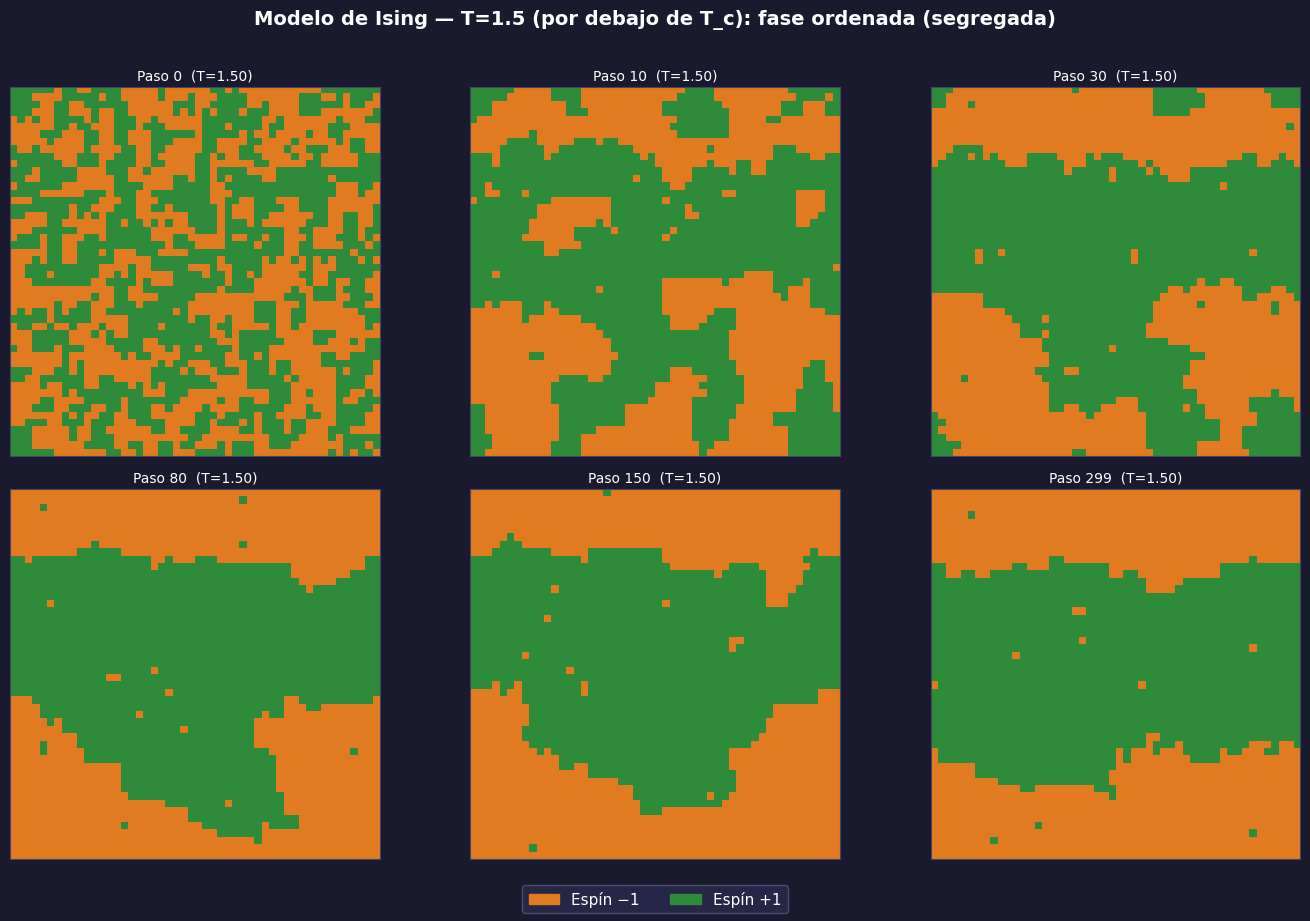

In [12]:
# ── Figura 6: Snapshots Ising T baja ─────────────────────────────────────────
plot_ising_snapshots(
    snaps_ising_frio, labels_ising_frio,
    titulo="Modelo de Ising — T=1.5 (por debajo de T_c): fase ordenada (segregada)",
    guardar_como="fig_ising_frio.png"
)


In [13]:
# ── Simulación de Ising a T alta (fase desordenada) ───────────────────────────
print('Corriendo modelo de Ising a T=3.5 (por encima de Tc ≈ 2.269)...')

snaps_ising_caliente, labels_ising_caliente, mag_caliente, _ = correr_ising(
    N=50, T=3.5, n_pasos=300, n_equilibrio=100,
    snapshots_en=[0, 10, 30, 80, 150, 299],
    seed=SEED
)

print(f'Magnetización media |<M>| = {np.mean(mag_caliente):.4f}  (esperado ≈ 0 para T>>Tc)')


Corriendo modelo de Ising a T=3.5 (por encima de Tc ≈ 2.269)...
Magnetización media |<M>| = 0.0357  (esperado ≈ 0 para T>>Tc)


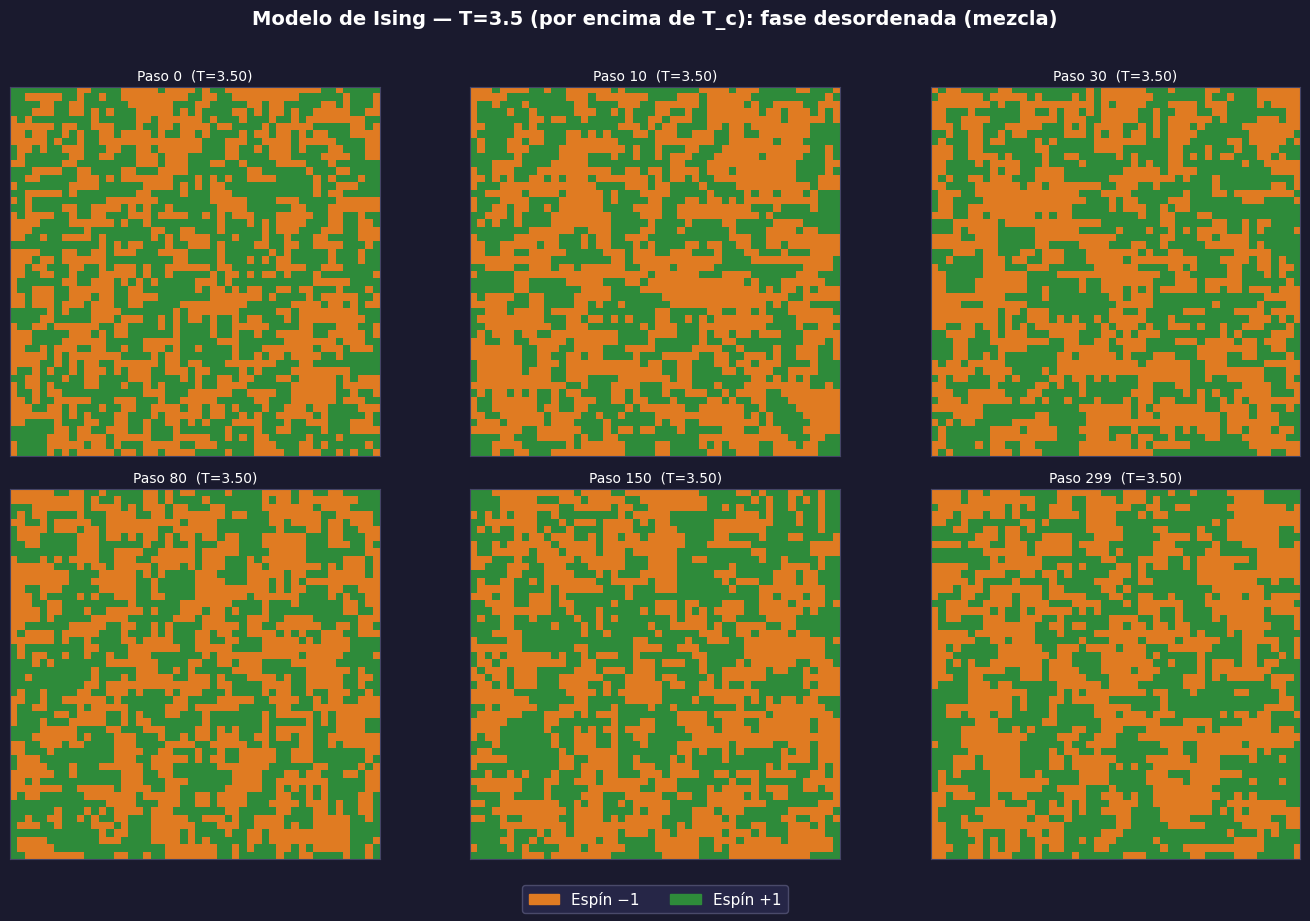

In [14]:
# ── Figura 7: Snapshots Ising T alta ─────────────────────────────────────────
plot_ising_snapshots(
    snaps_ising_caliente, labels_ising_caliente,
    titulo="Modelo de Ising — T=3.5 (por encima de T_c): fase desordenada (mezcla)",
    guardar_como="fig_ising_caliente.png"
)


Calculando curva M vs T (puede tardar ~2 minutos)...


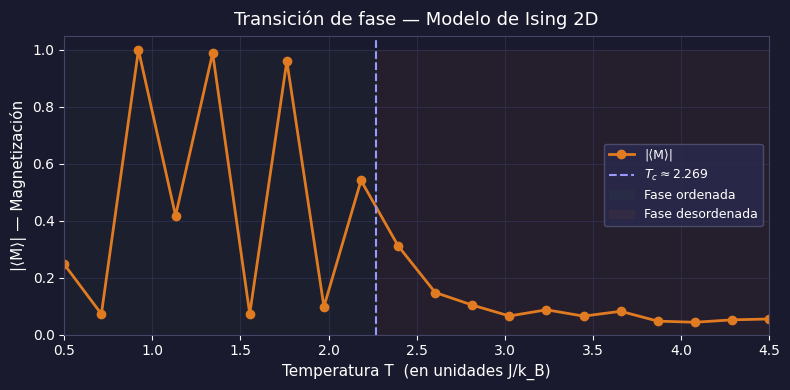


Tc numérica (caída más brusca de M): 0.711
Tc teórica (Onsager):                2.269


In [15]:
# ── Figura 8: Curva de transición de fase M vs T ──────────────────────────────
print('Calculando curva M vs T (puede tardar ~2 minutos)...')

Ts, Ms, Es = curva_magnetizacion_vs_temperatura(
    N=30, n_pasos=300, n_equilibrio=150,
    T_min=0.5, T_max=4.5, n_T=20, seed=SEED
)

plot_magnetizacion_vs_T(Ts, Ms, guardar_como="fig_ising_transicion.png")

# Encontrar Tc aproximada numéricamente
dM = np.abs(np.diff(Ms))
Tc_approx = Ts[np.argmax(dM)]
print(f'\nTc numérica (caída más brusca de M): {Tc_approx:.3f}')
print(f'Tc teórica (Onsager):                2.269')


---
## Punto 5 — MCMC con Cadenas de Markov para modelar segregación

### ¿El modelo de Schelling tiene estructura de cadena de Markov?

**Sí.** Una cadena de Markov es un proceso estocástico donde la distribución de probabilidad del estado futuro depende **únicamente del estado actual**, no del historial. El modelo de Schelling satisface esto:

> **Propiedad de Markov:** La probabilidad de que se produzca un intercambio en el paso $t+1$ depende solo de la configuración de la grilla en el paso $t$, no de cómo llegó a esa configuración.

El espacio de estados $\mathcal{S}$ consiste en todas las posibles asignaciones de tipos $\{0, 1, 2\}$ a las $N^2$ celdas → $|\mathcal{S}| = 3^{N^2}$ (exponencial, inmenso).

### ¿Es ergódica?

Para que la cadena tenga una distribución estacionaria única y accesible desde cualquier punto de partida, debe ser:
- **Irreducible:** Se puede llegar desde cualquier estado a cualquier otro estado. En Schelling con celdas vacías, sí (hay suficiente espacio para reconfigurar todo el sistema).
- **Aperiódica:** La cadena no entra en ciclos determinísticos. Con el elemento aleatorio en la selección de pares, sí (el sistema puede "quedarse" en el mismo estado si no hay pares descontentos).

**Conclusión:** La cadena de Schelling es ergódica ✓

### ¿Cómo se implementa con MCMC?

La clave conceptual es la **analogía con el modelo de Ising:**

Se puede definir una función de utilidad (pseudo-hamiltoniano):

$$U(\text{configuración}) = \sum_{\text{agentes}} \mathbb{1}[\text{agente contento}]$$

Y una distribución de Boltzmann:

$$\pi(\text{config}) \propto e^{U(\text{config}) / T_{\text{social}}}$$

donde $T_{\text{social}}$ es una "temperatura social" que representa el nivel de ruido en las decisiones (irracionalidad, información imperfecta).

**Metropolis-Hastings para Schelling:**
1. Proponer intercambio entre dos agentes aleatorios.
2. Calcular $\Delta U$ = cambio en utilidad total.
3. Aceptar si $\Delta U > 0$, o con probabilidad $e^{\Delta U / T}$ si $\Delta U \leq 0$.

Esto permite **muestrear la distribución de configuraciones** en lugar de solo simular una trayectoria determinista.

### Ventajas sobre la simulación directa:
- Podemos calcular promedios de equilibrio (no solo observar una trayectoria).
- La temperatura social $T$ permite modelar diferentes niveles de racionalidad.
- Convergencia garantizada por el teorema ergódico de MCMC.

### Limitaciones:
- El espacio de estados es $3^{2500}$ para una grilla 50×50 → el burn-in puede ser muy largo.
- El mixing time (tiempo hasta que la cadena "olvida" el punto de partida) puede ser enorme en sistemas con múltiples estados metaestables.
- La temperatura social es un parámetro sin interpretación directa en el contexto sociológico original.

In [16]:
# ── Demostración: Schelling con Metropolis-Hastings ───────────────────────────

def schelling_metropolis(grilla_inicial, T_social=1.0, n_pasos=200_000,
                          umbral=3/8, snapshots_en=None, seed=42):
    """
    Implementación de Schelling como cadena de Markov con criterio Metropolis.
    Permite moverse a configuraciones peores con probabilidad exp(ΔU/T_social).
    """
    from dynamics import fraccion_similares
    
    rng = np.random.default_rng(seed)
    grilla = grilla_inicial.copy()
    N = grilla.shape[0]
    
    if snapshots_en is None:
        snapshots_en = [0, 200, 800, 2000, 5000, n_pasos - 1]
    
    grillas_snap = [grilla.copy()]
    etiquetas    = ['Estado inicial']
    idx_snap = 1
    swaps = 0

    for intento in range(n_pasos):
        pos1 = list(zip(*np.where(grilla == 1)))
        pos2 = list(zip(*np.where(grilla == 2)))
        if not pos1 or not pos2:
            break

        f1, c1 = pos1[rng.integers(len(pos1))]
        f2, c2 = pos2[rng.integers(len(pos2))]

        # Utilidad antes del intercambio
        u_antes = (fraccion_similares(grilla, f1, c1) +
                   fraccion_similares(grilla, f2, c2))

        # Proponer intercambio
        grilla[f1, c1], grilla[f2, c2] = grilla[f2, c2], grilla[f1, c1]

        # Utilidad después del intercambio
        u_despues = (fraccion_similares(grilla, f1, c1) +
                     fraccion_similares(grilla, f2, c2))

        dU = u_despues - u_antes

        # Criterio Metropolis
        if dU >= 0 or rng.random() < np.exp(dU / T_social):
            swaps += 1  # aceptar
        else:
            # Rechazar: deshacer el intercambio
            grilla[f1, c1], grilla[f2, c2] = grilla[f2, c2], grilla[f1, c1]

        if idx_snap < len(snapshots_en) and swaps >= snapshots_en[idx_snap]:
            grillas_snap.append(grilla.copy())
            etiquetas.append(f'{swaps:,} intercambios')
            idx_snap += 1

    if len(grillas_snap) < 6:
        grillas_snap.append(grilla.copy())
        etiquetas.append(f'Final ({swaps:,})')

    return grillas_snap, etiquetas


# Ejecutar con T_social alta (más ruido → menos segregación)
print('Ejecutando Schelling-Metropolis con T_social=2.0...')
snaps_mcmc_caliente, labs_mcmc_caliente = schelling_metropolis(
    grilla_inicial, T_social=2.0, n_pasos=300_000,
    snapshots_en=[0, 100, 500, 1500, 4000, 8000], seed=SEED
)

# Ejecutar con T_social baja (menos ruido → más segregación)
print('Ejecutando Schelling-Metropolis con T_social=0.2...')
snaps_mcmc_frio, labs_mcmc_frio = schelling_metropolis(
    grilla_inicial, T_social=0.2, n_pasos=300_000,
    snapshots_en=[0, 100, 500, 1500, 4000, 8000], seed=SEED
)
print('Listo.')


Ejecutando Schelling-Metropolis con T_social=2.0...
Ejecutando Schelling-Metropolis con T_social=0.2...
Listo.


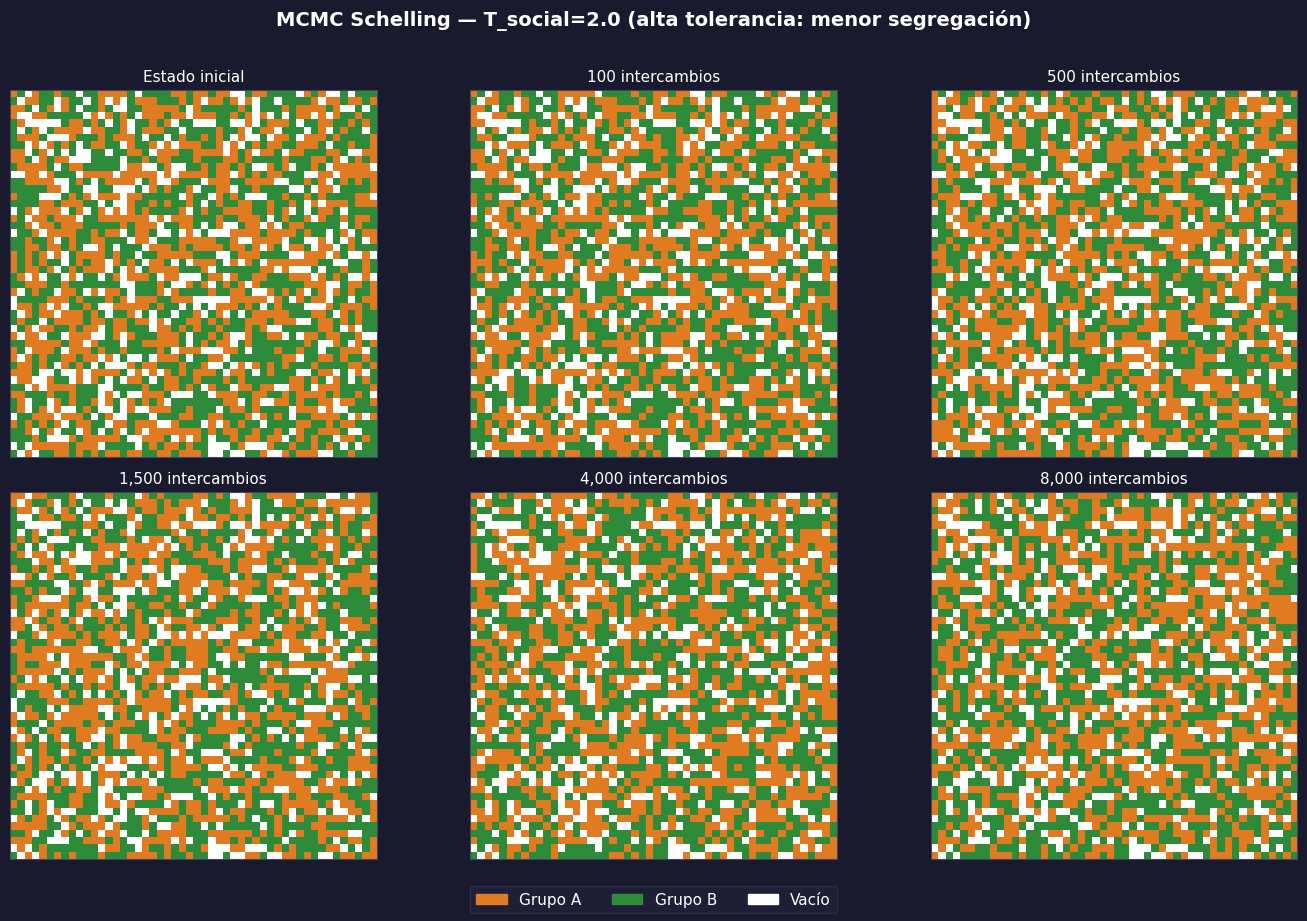

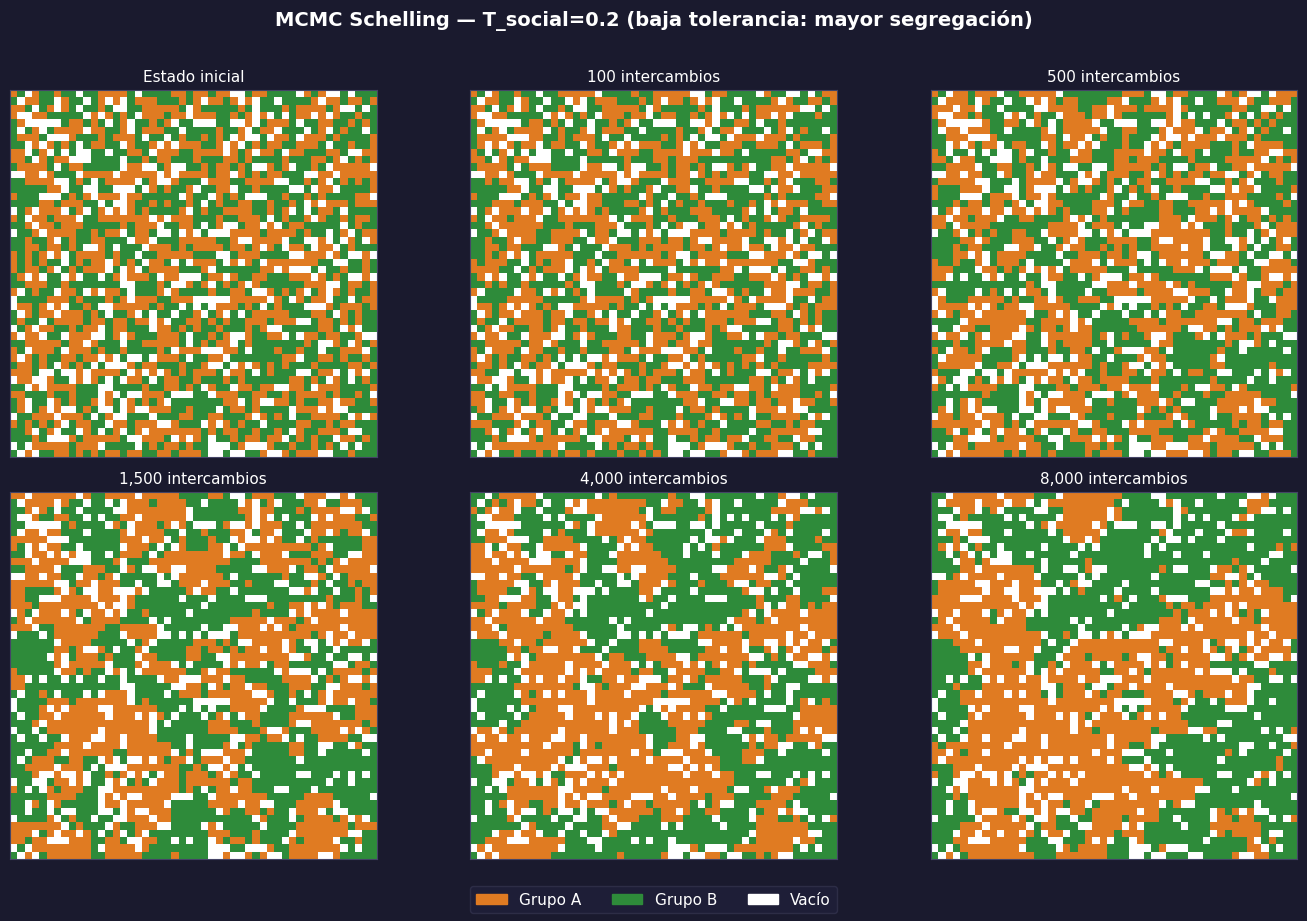

In [17]:
# ── Figura 9: MCMC Schelling con T social alta ────────────────────────────────
from visualization import CMAP, NORM

plot_snapshots(
    snaps_mcmc_caliente, labs_mcmc_caliente,
    titulo="MCMC Schelling — T_social=2.0 (alta tolerancia: menor segregación)",
    guardar_como="fig_mcmc_caliente.png"
)

plot_snapshots(
    snaps_mcmc_frio, labs_mcmc_frio,
    titulo="MCMC Schelling — T_social=0.2 (baja tolerancia: mayor segregación)",
    guardar_como="fig_mcmc_frio.png"
)


In [18]:
# ── Resumen final de métricas MCMC ────────────────────────────────────────────
print('RESUMEN — Segregación final por método y temperatura:')
print(f'  Dinámica 2 (Schelling estándar):          similitud = {indice_similitud(snaps_d2[-1]):.3f}')
print(f'  MCMC T_social=0.2 (baja tolerancia):     similitud = {indice_similitud(snaps_mcmc_frio[-1]):.3f}')
print(f'  MCMC T_social=2.0 (alta tolerancia):     similitud = {indice_similitud(snaps_mcmc_caliente[-1]):.3f}')
print()
print('Conclusión:')
print('La temperatura social T controla el nivel de segregación emergente:')
print('  T → 0  : segregación máxima (análogo a Schelling estricto)')
print('  T → ∞  : distribución aleatoria uniforme (sin segregación)')
print('  T = Tc : transición de fase (región crítica, estructuras fractales)')


RESUMEN — Segregación final por método y temperatura:
  Dinámica 2 (Schelling estándar):          similitud = 0.829
  MCMC T_social=0.2 (baja tolerancia):     similitud = 0.834
  MCMC T_social=2.0 (alta tolerancia):     similitud = 0.507

Conclusión:
La temperatura social T controla el nivel de segregación emergente:
  T → 0  : segregación máxima (análogo a Schelling estricto)
  T → ∞  : distribución aleatoria uniforme (sin segregación)
  T = Tc : transición de fase (región crítica, estructuras fractales)


---
## Conclusiones Generales

### 1. Emergencia de comportamiento colectivo
Ambas dinámicas demuestran que el comportamiento macro de un sistema social puede ser radicalmente diferente — y muchas veces opuesto — a las intenciones individuales de sus agentes. Schelling denominó esto el problema de la *micro-macro conexión*.

### 2. Frustración y equilibrio de Nash
En la Dinámica 1, la frustración es un ejemplo de ausencia de equilibrio de Nash: no existe ninguna configuración donde todos los agentes sean simultáneamente óptimos. El sistema oscila eternamente sin converger.

### 3. La paradoja de Schelling
La Dinámica 2 revela la paradoja central: una preferencia individual muy suave (solo quiero que 3/8 de mis vecinos sean iguales a mí, o sea acepto que el 62.5% sean diferentes) genera segregación total a nivel macro. Esto tiene implicaciones importantes para política pública: **no alcanza con que cada individuo tolere la diversidad** — la dinámica de mudanzas puede generar segregación de todas formas.

### 4. Ising como puente entre física y sociología
La equivalencia formal entre el modelo de Ising y el de Schelling muestra que los fenómenos de segregación/orden son **universales**: aparecen en sistemas de spines magnéticos, en segregación residencial, en formación de opiniones políticas, y en competencia entre especies. El concepto de temperatura crítica $T_c$ tiene análogos en todos estos contextos.

### 5. MCMC como generalización
El enfoque MCMC permite tratar el modelo de Schelling como un problema de inferencia estadística: en lugar de simular una trayectoria, muestreamos la distribución de todas las configuraciones posibles ponderadas por su utilidad. La temperatura social $T$ parametriza el espectro completo entre segregación máxima ($T \to 0$) y mezcla aleatoria ($T \to \infty$).